In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import gamma
import pandas as pd

/opt/apps/rhel8/Anaconda3-2021.05/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Imagine that Kiwi Airlines flies jets with seats for 160 passengers. The airline makes $200 profit on
each reservation, regardless of whether the passengers show up or not. (Reservations are nonrefundable.)

 In overbooking situations, Kiwi Airlines gives passengers a full refund and $100 credit
towards a future flight

Finally, the average no-show rate is 5% and get no refund for missing

1a. Your goal is to determine how many reservations (r) Kiwi should sell for each flight.
a. If Kiwi sells 160 reservations, what is the distribution of the number of passengers (x) actually
showing up for the flight? Plot this distribution of x.

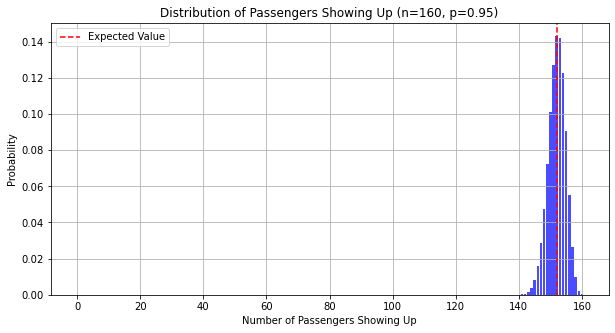

In [4]:
# using binomial distribution because it is a yes or now for showing up
# Parameters
n_reservations = 160  # Total reservations made
p_show = 0.95         # Probability of a passenger showing up

# Possible values for the number of passengers showing up
x = np.arange(n_reservations + 1)

# Binomial probability mass function
pmf = stats.binom.pmf(x, n_reservations, p_show)

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.bar(x, pmf, color='blue', alpha=0.7)
plt.xlabel("Number of Passengers Showing Up")
plt.ylabel("Probability")
plt.title(f"Distribution of Passengers Showing Up (n={n_reservations}, p={p_show})")
plt.axvline(n_reservations * p_show, color='red', linestyle='dashed', label="Expected Value")
plt.legend()
plt.grid()
plt.show()


No handles with labels found to put in legend.


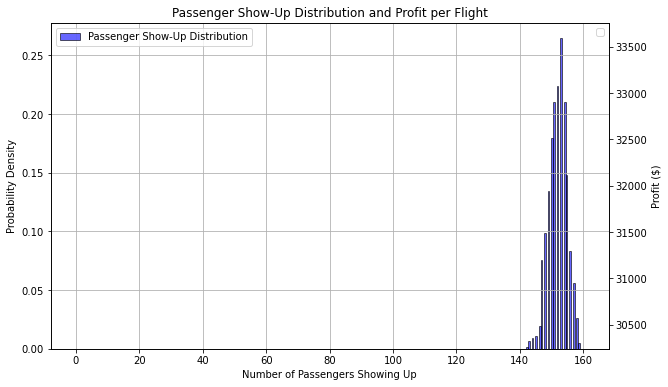

In [10]:
#1b cost function
# Plot the cost function, consisting of both overbooking (future flight credits) and underbooking
# (lost profit) superimposed on your distribution from part a.
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Given parameters
n_reservations = 160  # Total reservations made
p_show = 0.95         # Probability of a passenger showing up
ticket_price = 200     # Profit per reservation
credit_per_bumped = 100  # Extra credit for overbooking
seats_available = 160  # Number of available seats

# Generate 1000 samples from the binomial distribution
samples = stats.binom.rvs(n_reservations, p_show, size=1000)

# Compute profit for each possible number of passengers
unique_passengers = np.arange(n_reservations + 1)  # Possible values (0 to 160)
pmf = stats.binom.pmf(unique_passengers, n_reservations, p_show)  # Probability distribution

# Calculate profit based on number of passengers
fixed_revenue = n_reservations * ticket_price  # Revenue from all reservations
profit_values = []
for passengers in unique_passengers:
    if passengers <= seats_available:
        profit_values.append(fixed_revenue)  # No extra costs
    else:
        bumped_passengers = passengers - seats_available
        refund_cost = bumped_passengers * ticket_price
        credit_cost = bumped_passengers * credit_per_bumped
        total_cost = refund_cost + credit_cost
        profit_values.append(fixed_revenue - total_cost)

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram of simulated passenger show-ups
ax1.hist(samples, bins=30, density=True, alpha=0.6, color='b', edgecolor='black', label="Passenger Show-Up Distribution")
ax1.set_xlabel("Number of Passengers Showing Up")
ax1.set_ylabel("Probability Density")
ax1.set_title("Passenger Show-Up Distribution and Profit per Flight")
ax1.grid(True)

# Add secondary axis for profit
#1b look at the second Y axis 
#I added the cost of each iteration of possible people assuming 160 is the max booking amount
ax2 = ax1.twinx()
ax2.plot(unique_passengers, profit_values, color='white', linestyle='-', linewidth=0)
ax2.set_ylabel("Profit ($)")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()


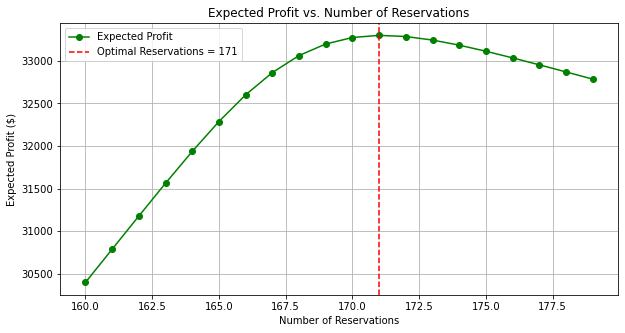

Optimal number of reservations: 171
Maximum expected profit: $33297.63


In [6]:
#1c maximize profits kinda confused why the question want to minimize costs I assume that is overall cost not just the flight credit cost because if it is flight credit cost then we would sell nothing

# Parameters
n_seats = 160         # Fixed number of available seats
p_show = 0.95         # Probability of a passenger showing up

# Cost parameters
ticket_profit = 200    # Profit per reservation
overbooking_penalty = 300  # Refund + credit per overbooked passenger
underbooking_penalty = 200 # Lost profit per empty seat

# Range of possible reservations (overbooking scenario)
#n_reservations_range = x
n_reservations_range = np.arange(n_seats, n_seats + 20)  # Testing different overbooking levels

# Initialize storage for expected profits
expected_profits = []

# Loop over different reservation levels
for n_reservations in n_reservations_range:
    # Possible number of passengers showing up
    x = np.arange(n_reservations + 1)

    # Compute probability mass function (PMF)
    pmf = stats.binom.pmf(x, n_reservations, p_show)

    # Compute profit for each scenario
    profit = (n_reservations * ticket_profit) - \
             (np.maximum(0, x - n_seats) * overbooking_penalty) - \
             (np.maximum(0, n_seats - x) * underbooking_penalty)

    # Expected profit (weighted sum using PMF)
    expected_profit = np.sum(profit * pmf)
    expected_profits.append(expected_profit)

# Find the optimal number of reservations
optimal_n_reservations = n_reservations_range[np.argmax(expected_profits)]
optimal_profit = max(expected_profits)

# Plot the expected profit vs. reservation levels
plt.figure(figsize=(10, 5))
plt.plot(n_reservations_range, expected_profits, marker='o', linestyle='-', color='green', label="Expected Profit")
plt.axvline(optimal_n_reservations, color='red', linestyle='dashed', label=f"Optimal Reservations = {optimal_n_reservations}")
plt.xlabel("Number of Reservations")
plt.ylabel("Expected Profit ($)")
plt.title("Expected Profit vs. Number of Reservations")
plt.legend()
plt.grid()
plt.show()

print(f"Optimal number of reservations: {optimal_n_reservations}")
print(f"Maximum expected profit: ${optimal_profit:.2f}")


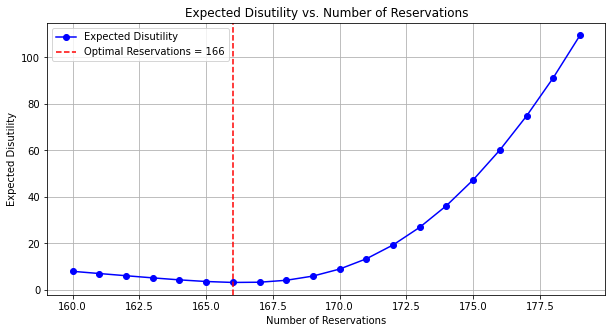

Optimal number of reservations: 166
Minimum expected disutility: 3.22


In [11]:
#1D
# Parameters
n_seats = 160         # Fixed number of available seats
p_show = 0.95         # Probability of a passenger showing up

# Range of possible reservations (testing different overbooking levels)
n_reservations_range = np.arange(n_seats, n_seats + 20)

# Initialize storage for expected disutilities
expected_disutilities = []

# Loop over different reservation levels
for n_reservations in n_reservations_range:
    # Possible number of passengers showing up
    x = np.arange(n_reservations + 1)

    # Compute probability mass function (PMF)
    pmf = stats.binom.pmf(x, n_reservations, p_show)

    # Compute disutilities
    y = np.maximum(0, x - n_seats)  # Number of bumped passengers
    z = np.maximum(0, n_seats - x)  # Number of empty seats

    # Disutility functions
    disutility = (y ** 2) + z  # Do(y) = y^2, Du(z) = z

    # Expected disutility (weighted sum using PMF)
    expected_disutility = np.sum(disutility * pmf)
    expected_disutilities.append(expected_disutility)

# Find the optimal number of reservations
optimal_n_reservations = n_reservations_range[np.argmin(expected_disutilities)]
optimal_disutility = min(expected_disutilities)

# Plot the expected disutility vs. reservation levels
plt.figure(figsize=(10, 5))
plt.plot(n_reservations_range, expected_disutilities, marker='o', linestyle='-', color='blue', label="Expected Disutility")
plt.axvline(optimal_n_reservations, color='red', linestyle='dashed', label=f"Optimal Reservations = {optimal_n_reservations}")
plt.xlabel("Number of Reservations")
plt.ylabel("Expected Disutility")
plt.title("Expected Disutility vs. Number of Reservations")
plt.legend()
plt.grid()
plt.show()

print(f"Optimal number of reservations: {optimal_n_reservations}")
print(f"Minimum expected disutility: {optimal_disutility:.2f}")


In [ ]:
#2. Bayesian parameter inference using income data

In [40]:
#2a gama distribution a = 3 b = 2

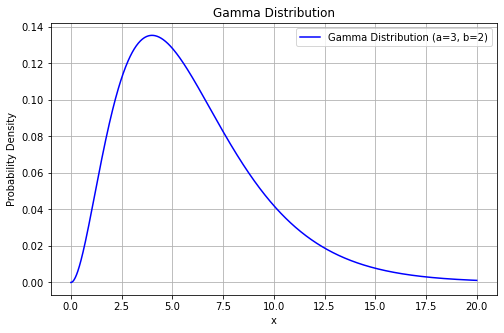

In [3]:
# given
a = 3  # Shape parameter
b = 2  # Scale parameter

# Generate x values 
x = np.linspace(0, 20, 1000)

# Compute the gamma probability density function (PDF)
y = gamma.pdf(x, a, scale=b)

# Plot the gamma distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Gamma Distribution (a={a}, b={b})', color='blue')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Gamma Distribution')
plt.legend()
plt.grid()
plt.show()


In [4]:
sp500 = pd.read_excel("SP500_2020.xlsx")
print(sp500.head())

        Date    Return
0 2020-01-03 -0.007060
1 2020-01-06  0.003533
2 2020-01-07 -0.002803
3 2020-01-08  0.004902
4 2020-01-09  0.006655


In [5]:
# Calculate the mean of the Return column
mean_return = sp500['Return'].mean()

# Subtract the mean from each value in the Return column
sp500['Return'] = (sp500['Return'] - mean_return) * 100

# Print the updated DataFrame
print(sp500.head())


        Date    Return
0 2020-01-03 -0.786210
1 2020-01-06  0.273117
2 2020-01-07 -0.360543
3 2020-01-08  0.410019
4 2020-01-09  0.585307


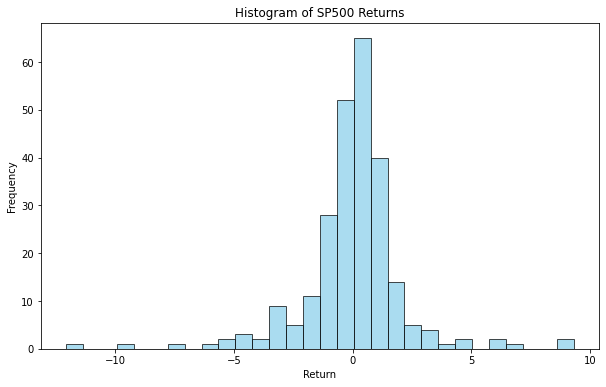

In [6]:
plt.figure(figsize=(10,6))
plt.hist(sp500['Return'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Histogram of SP500 Returns')

# Show the plot
plt.show()

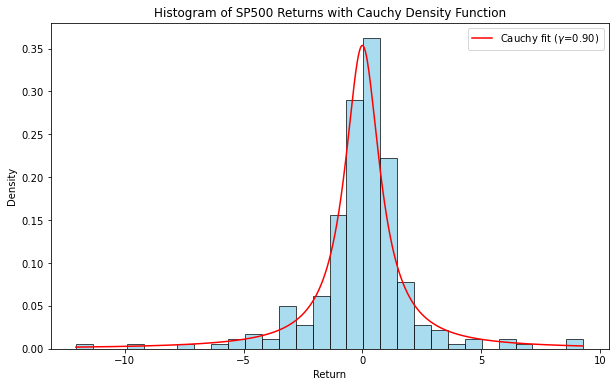

In [11]:
# Fit a Cauchy distribution to the data by choosing reasonable x0 and gamma
x0 = sp500['Return'].mean()  # Use the mean of Return as the location parameter

#trying different gammas
#gamma = sp500['Return'].std()  # Use the standard deviation as an estimate for gamma
gamma = .9

# Create a range of values for x (from min to max of the Return column)
x_range = np.linspace(sp500['Return'].min(), sp500['Return'].max(), 1000)

# Cauchy density function
cauchy_pdf = (1 / (np.pi * gamma * (1 + ((x_range - x0) / gamma) ** 2)))

# Plot the histogram
plt.figure(figsize=(10,6))
plt.hist(sp500['Return'], bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)

# Plot the Cauchy distribution
plt.plot(x_range, cauchy_pdf, color='red', label=f'Cauchy fit ($\\gamma$={gamma:.2f})')

# Set labels and title
plt.xlabel('Return')
plt.ylabel('Density')
plt.title('Histogram of SP500 Returns with Cauchy Density Function')

# Show legend
plt.legend()

# Show the plot
plt.show()


Mean of samples: -0.5588
Standard deviation of samples: 1.8214
Acceptance rate: 77.20%


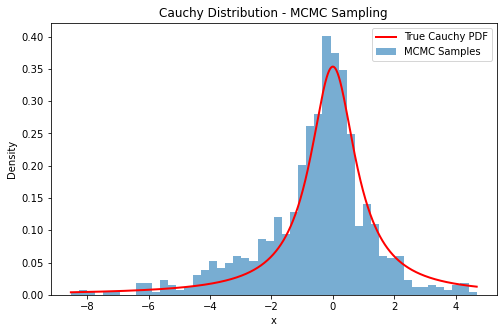

In [26]:
# Given parameters
gamma = 0.9  # Scale parameter
x0 =sp500['Return'].mean()# 0  # Location parameter 
num_samples = 1000  # Number of MCMC samples

# Define the Cauchy PDF
#cauchy_pdf = (1 / (np.pi * gamma * (1 + ((x_range - x0) / gamma) ** 2)))

def cauchy_pdf(x, x0, gamma):
    return 1 / (np.pi * gamma * (1 + ((x - x0) / gamma) ** 2))

# Metropolis-Hastings MCMC sampler with acceptance rate tracking
def metropolis_hastings_cauchy(x0, gamma, num_samples, proposal_std=1.0):
    samples = []
    current_x = x0  # Start at the mean
    accepted = 0  # Track accepted proposals

    for _ in range(num_samples):
        # Propose a new sample from a normal distribution centered at current_x
        proposed_x = np.random.normal(current_x, proposal_std) # this is the jump distribution
        #proposed_x = current_x + np.random.standard_cauchy() * proposal_scale # cauchy proposal large jumps and better exploration of the long tails of the Cauchy distribution.
        #proposed_x = current_x + np.random.uniform(-delta, delta) #uniform steps
        # Compute acceptance probability
        acceptance_ratio = cauchy_pdf(proposed_x, x0, gamma) / cauchy_pdf(current_x, x0, gamma)
        
        # Accept/reject step
        if np.random.rand() < min(1, acceptance_ratio):
            current_x = proposed_x
            accepted += 1  # Count accepted samples
        
        samples.append(current_x)
    
    acceptance_rate = accepted / num_samples
    return np.array(samples), acceptance_rate

# Generate samples
samples, acceptance_rate = metropolis_hastings_cauchy(x0, gamma, num_samples)

# Compute statistics
mean_sample = np.mean(samples)
std_sample = np.std(samples)

# Print statistics
# 2 b
print(f"Mean of samples: {mean_sample:.4f}")
print(f"Standard deviation of samples: {std_sample:.4f}")
print(f"Acceptance rate: {acceptance_rate:.2%}")

# Plot histogram of samples
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='MCMC Samples')

# Overlay true Cauchy PDF
x_range = np.linspace(min(samples), max(samples), 1000)
plt.plot(x_range, cauchy_pdf(x_range, x0, gamma), 'r-', lw=2, label='True Cauchy PDF')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Cauchy Distribution - MCMC Sampling')
plt.legend()
plt.show()



Mean of samples: 0.6237
Standard deviation of samples: 3.5944
Acceptance rate: 40.08%


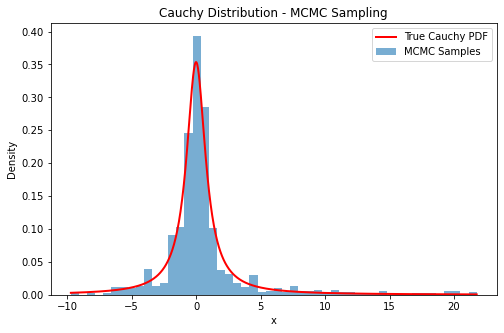

In [37]:
# Given parameters
gamma = 0.9  # Scale parameter
x0 = sp500['Return'].mean()  # Location parameter 
num_samples = 1000  # Number of MCMC samples

def cauchy_pdf(x, x0, gamma):
    return 1 / (np.pi * gamma * (1 + ((x - x0) / gamma) ** 2))

def metropolis_hastings_cauchy(x0, gamma, num_samples, burn_in=200, target_acceptance=(0.4, 0.5)):
    proposal_std = 1.0  # Initial proposal standard deviation
    burn_in = int(burn_in)
    samples = []
    current_x = x0
    accepted = 0
    tuning_iterations = 100  # Number of iterations before tuning

    for i in range(num_samples):
        # Propose a new sample
        proposed_x = np.random.normal(current_x, proposal_std) # this is the jump distribution
        #proposed_x = current_x + np.random.standard_cauchy() * proposal_scale # cauchy proposal large jumps and better exploration of the long tails of the Cauchy distribution.
        #proposed_x = current_x + np.random.uniform(-delta, delta) #uniform steps
        
        # Compute acceptance probability
        acceptance_ratio = cauchy_pdf(proposed_x, x0, gamma) / cauchy_pdf(current_x, x0, gamma)
        
        # Accept/reject step
        if np.random.rand() < min(1, acceptance_ratio):
            current_x = proposed_x
            accepted += 1
#2c this is my burn in         
        if i >= burn_in:  # Only store samples after burn-in
            samples.append(current_x)
#2c this is where I adjust the jump distribution to be in the 40-50% criteria        
        # Adjust proposal_std every tuning_iterations
        if (i + 1) % tuning_iterations == 0:
            acceptance_rate = accepted / (i + 1)
            if acceptance_rate < target_acceptance[0]:
                proposal_std *= 0.7  # Reduce step size if acceptance is too low
            elif acceptance_rate > target_acceptance[1]:
                proposal_std *= 1.3  # Increase step size if acceptance is too high
    
    acceptance_rate = accepted / (num_samples + burn_in)
    return np.array(samples), acceptance_rate

# Generate samples with burn-in
samples, acceptance_rate = metropolis_hastings_cauchy(x0, gamma, num_samples, burn_in=200)

# Compute statistics
mean_sample = np.mean(samples)
std_sample = np.std(samples)
#2d -----------------
# Print statistics
print(f"Mean of samples: {mean_sample:.4f}")
print(f"Standard deviation of samples: {std_sample:.4f}")
print(f"Acceptance rate: {acceptance_rate:.2%}")

# Plot histogram of samples
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='MCMC Samples')

# Overlay true Cauchy PDF
x_range = np.linspace(min(samples), max(samples), 1000)
plt.plot(x_range, cauchy_pdf(x_range, x0, gamma), 'r-', lw=2, label='True Cauchy PDF')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Cauchy Distribution - MCMC Sampling')
plt.legend()
plt.show()


In [38]:
#2e
# Compute the probability that gamma is less than 0.7
prob_gamma_less_than_0_7 = np.mean(samples < 0.7)

# Compute the probability that gamma is greater than 0.8
prob_gamma_greater_than_0_8 = np.mean(samples > 0.8)

# Print the results
print(f"Probability that gamma is less than 0.7: {prob_gamma_less_than_0_7:.4f}")
print(f"Probability that gamma is greater than 0.8: {prob_gamma_greater_than_0_8:.4f}")


Probability that gamma is less than 0.7: 0.6787
Probability that gamma is greater than 0.8: 0.2412


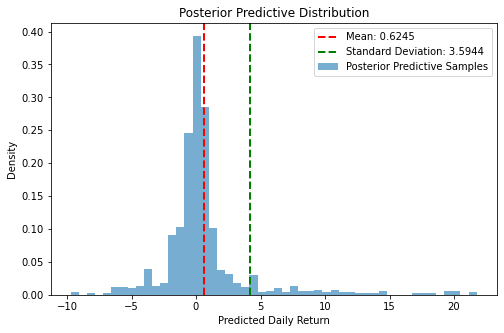

Mean of posterior predictive samples: 0.6245
Standard deviation of posterior predictive samples: 3.5944
Probability that the predicted value is less than -1%: 0.4425
Probability that the predicted value is greater than 1%: 0.5425


In [39]:
#2f

# Generate posterior predictive samples
# These samples represent a single new observation prediction
posterior_predictive_samples = samples + mean_return  # Add back the overall mean value

# Plot the histogram of posterior predictive samples
plt.figure(figsize=(8, 5))
plt.hist(posterior_predictive_samples, bins=50, density=True, alpha=0.6, label='Posterior Predictive Samples')

# Plot the mean and std on the histogram
plt.axvline(np.mean(posterior_predictive_samples), color='r', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(posterior_predictive_samples):.4f}')
plt.axvline(np.mean(posterior_predictive_samples) + np.std(posterior_predictive_samples), color='g', linestyle='dashed', linewidth=2, label=f'Standard Deviation: {np.std(posterior_predictive_samples):.4f}')

plt.xlabel('Predicted Daily Return')
plt.ylabel('Density')
plt.title('Posterior Predictive Distribution')
plt.legend()
plt.show()

# Compute the mean and standard deviation of the posterior predictive samples
mean_predictive = np.mean(posterior_predictive_samples)
std_predictive = np.std(posterior_predictive_samples)

# Print mean and standard deviation
print(f"Mean of posterior predictive samples: {mean_predictive:.4f}")
print(f"Standard deviation of posterior predictive samples: {std_predictive:.4f}")

# Calculate the probabilities
prob_less_than_minus_1_percent = np.mean(posterior_predictive_samples < -0.01)
prob_greater_than_1_percent = np.mean(posterior_predictive_samples > 0.01)

# Print the probabilities
print(f"Probability that the predicted value is less than -1%: {prob_less_than_minus_1_percent:.4f}")
print(f"Probability that the predicted value is greater than 1%: {prob_greater_than_1_percent:.4f}")
